This notebook is to play around with gui code for visualizing data online

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import hydra
from hydra.utils import get_original_cwd
import os
from omegaconf import DictConfig, OmegaConf
from dataclasses import dataclass
from typing import List, Dict, Any

In [ ]:
# Load config
import sys
import os
from pathlib import Path


# Add the parent directory to the path so we can import modules properly
cwd = Path.cwd()
print(f"home directory: {cwd}")
relative_repo_path = "GitRepos/simulation_closed_loop"

# append repo path 
sys.path.append(str(cwd / relative_repo_path))

# Import Hydra config utilities
from omegaconf import DictConfig, OmegaConf
import hydra
from hydra.utils import instantiate
from hydra.core.config_store import ConfigStore
from hydra import compose, initialize

# Initialize Hydra with the relative path to the config directory
config_path = os.path.join(relative_repo_path,"config")
print(f"Config path: {config_path}")

# Initialize Hydra
with initialize(version_base="1.3", config_path=config_path):
    # Compose the configuration
    cfg = compose(config_name="config")

# Print the config to verify it loaded correctly
print("Configuration loaded successfully:")
print(OmegaConf.to_yaml(cfg))

home directory: /gpfs01/euler/User/ssuhai
Config path: GitRepos/simulation_closed_loop/config
Configuration loaded successfully:
data_subfolders:
  day: 20250717
  experiment: 1
DJ:
  username: ssuhai
  userinfo:
    experimenter: closedlooptest
    animal_loc: 1
    region_loc: 2
    field_loc: 3
    stimulus_loc: 4
    cond1_loc: 5
    data_dir: /gpfs01/euler/User/ssuhai/GitRepos/simulation_closed_loop/data/recordings/updated_loop_data
  table_parameters:
    PreprocessParams:
      window_length: 60
      poly_order: 3
      non_negative: 1
      subtract_baseline: 0
      standardize: 1
    Stimulus:
      noise:
        stim_name: densenoise
        stim_family: noise
        pix_n_x: 20
        pix_n_y: 15
        skip_duplicates: true
        pix_scale_x_um: 40
        pix_scale_y_um: 40
        framerate: 5
    DNoiseTraceParams:
      dnoise_params_id: 1
      fupsample_trace: 20
      fupsample_stim: 4
      ref_time: stim
      fit_kind: gradient
      skip_duplicates: true


In [4]:
cfg.paths.repo_directory

'/gpfs01/euler/User/ssuhai/GitRepos/simulation_closed_loop/'

In [5]:
# # hydra in notebooks behaves differently. 
# # Need to overwrite the configs dynamicaly set at runtime 
# from datetime import datetime
# output_dir = f"{cfg.paths.repo_directory}/logs/outputs/{datetime.now().strftime('%Y-%m-%d_%H-%M-%S')}"
# OmegaConf.update(cfg, "model_configs.paths.output_dir", output_dir)


In [26]:
cfg.model_configs.paths.output_dir

'output'

In [4]:
# 
from simulations.loop_components.dj_wrappers import DJTableHolder,Preprocessor,QualityAndTypeWrapper,STAWrapper,RandomSeedMEIWrapper

# connect populated closed loop schema

In [5]:
# create preprocessor
os.environ["DJ_SUPPORT_FILEPATH_MANAGEMENT"] = "TRUE"

dj_table_holder = DJTableHolder(
                username=cfg.DJ.username, # type: ignore
                
                #paths
                home_directory=cfg.paths.home_directory, # type: ignore
                repo_directory=cfg.paths.repo_directory, # type: ignore
                dj_config_directory= cfg.paths.dj_config_directory, # type: ignore
                rgc_output_directory= cfg.paths.rgc_output_directory, # type: ignore
                data_subfolders=cfg.data_subfolders, # type: ignore


                userinfo= cfg.DJ.userinfo, # type: ignore

                table_parameters=cfg.DJ.table_parameters, # type: ignore

                # from overall configs
                debug=cfg.debug, # type: ignore
                plot_results=cfg.plot_results, # type: ignore

                    )

In [6]:
preprocessor = Preprocessor(dj_table_holder=dj_table_holder)

In [9]:
quality_type_analysis_wrapper = QualityAndTypeWrapper(
    dj_table_holder=dj_table_holder,)

sta_wrapper = STAWrapper(
    dj_table_holder=dj_table_holder,)

randomp_seed_mei_wrapper = RandomSeedMEIWrapper(
    dj_table_holder=dj_table_holder,
    model_configs=cfg.model_configs, 
    seeds= [123,456,789])

In [8]:
# # Load config and tables

dj_table_holder.load_config()
dj_table_holder.load_tables()
# dj_table_holder.clear_tables("all")

# print(" loaded and configured successfully")
#dj_table_holder.setup()




[2025-07-31 16:53:39,657][INFO]: Connecting ssuhai@172.25.240.200:3306
[2025-07-31 16:53:39,718][INFO]: Connected ssuhai@172.25.240.200:3306


schema_name: ageuler_ssuhai_closed_loop


In [12]:
preprocessor.upload_iteration_metadata()

Scanning for experimenter: closedlooptest
	header_path: /gpfs01/euler/User/ssuhai/GitRepos/simulation_closed_loop/data/recordings/updated_loop_data/20200226/1
		header_name: 20200226__left.ini
		Adding: {'experimenter': 'closedlooptest', 'date': datetime.datetime(2020, 2, 26, 0, 0), 'exp_num': 1}


OpticDisk: 100%|██████████| 1/1 [00:00<00:00, 29.18it/s]


Found 4 files in 1 fields for key={'experimenter': 'closedlooptest', 'date': datetime.date(2020, 2, 26), 'exp_num': 1, 'raw_id': 1}
	Adding field: `{'field': 'GCL0', 'region': 'LR', 'cond1': 'iter0', 'experimenter': 'closedlooptest', 'date': datetime.date(2020, 2, 26), 'exp_num': 1, 'raw_id': 1}`


Processes: 100%|██████████| 6/6 [00:07<00:00,  1.33s/it]


# GUI Components for Visualization

Let's create a basic GUI to visualize the data processed by the OpenRetinaWrapper.

In [10]:
missing_keys = dj_table_holder("RoiMask")().list_missing_field()
if missing_keys == []:
    missing_keys = [dj_table_holder("Field")().proj().fetch1()]

missing_keys


[{'experimenter': 'closedlooptest',
  'date': datetime.date(2020, 2, 26),
  'exp_num': 1,
  'raw_id': 1,
  'field': 'GCL0',
  'region': 'LR',
  'cond1': 'iter0'}]

# modified autorois 

In [12]:
dj_table_holder("Traces")()

experimenter name of the experimenter,date date of recording,exp_num experiment number in a day,raw_id unique param set id,field string identifying files corresponding to field,region region (e.g. LR or RR),cond1 condition (pharmacological or other),stim_name Unique string identifier,cond2 condition (pharmacological or other),roi_id integer id of each ROI,trace array of raw trace,trace_t0 numerical array of trace times,trace_dt time between frames,trace_valid Are values in trace correct (1) or not (0)?,trigger_valid Are triggertimes inside trace_times (1) or not (0)?
closedlooptest,2020-02-26,1,1,GCL0,LR,iter0,densenoise,control,1,=BLOB=,0.002,0.128,1,1
closedlooptest,2020-02-26,1,1,GCL0,LR,iter0,densenoise,control,2,=BLOB=,0.002,0.128,1,1
closedlooptest,2020-02-26,1,1,GCL0,LR,iter0,densenoise,control,3,=BLOB=,0.0,0.128,1,1
closedlooptest,2020-02-26,1,1,GCL0,LR,iter0,densenoise,control,4,=BLOB=,0.008,0.128,1,1
closedlooptest,2020-02-26,1,1,GCL0,LR,iter0,densenoise,control,5,=BLOB=,0.003,0.128,1,1
closedlooptest,2020-02-26,1,1,GCL0,LR,iter0,densenoise,control,6,=BLOB=,0.006,0.128,1,1
closedlooptest,2020-02-26,1,1,GCL0,LR,iter0,densenoise,control,7,=BLOB=,0.012,0.128,1,1
closedlooptest,2020-02-26,1,1,GCL0,LR,iter0,densenoise,control,8,=BLOB=,0.006,0.128,1,1
closedlooptest,2020-02-26,1,1,GCL0,LR,iter0,densenoise,control,9,=BLOB=,0.01,0.128,1,1
closedlooptest,2020-02-26,1,1,GCL0,LR,iter0,densenoise,control,10,=BLOB=,0.013,0.128,1,1


In [11]:
from simulations.gui.integrated_autorois import InteractiveRoiCanvas
# import ipywidgets as widgets
# from ipycanvas import MultiCanvas
from IPython.display import display

Load model weights for cpu from checkpoint /gpfs01/euler/data/Resources/AutoROIs/models/UNET_v0.1.0/dropout_and_aug_regul.ckpt using config /gpfs01/euler/data/Resources/AutoROIs/models/UNET_v0.1.0/sd_images.yaml


<Figure size 640x480 with 0 Axes>

Upsampling natural spikes traces to get final responses.:   0%|          | 0/1 [00:00<?, ?it/s]

Creating movie dataloaders:   0%|          | 0/1 [00:00<?, ?it/s]

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Testing: |          | 0/? [00:00<?, ?it/s]

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

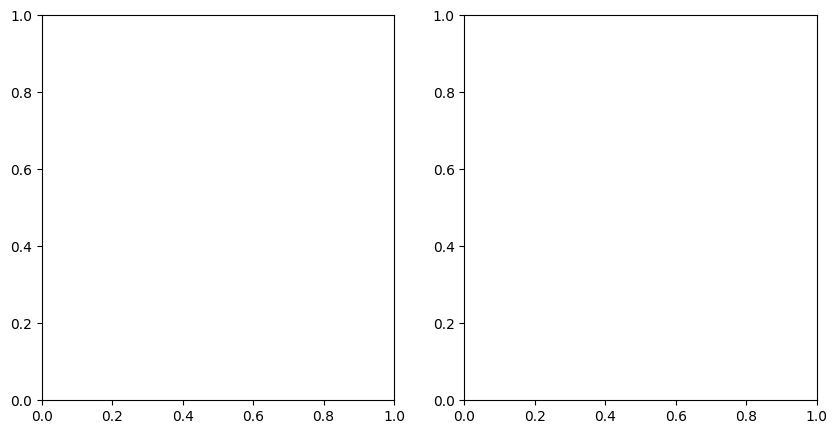

<Figure size 640x480 with 0 Axes>

In [13]:
mod_autorois = InteractiveRoiCanvas(
    dj_table_holder=dj_table_holder,
    dj_preprocessor=preprocessor,
    all_dj_wrappers=[quality_type_analysis_wrapper,sta_wrapper,randomp_seed_mei_wrapper],
    field_key=missing_keys[0],
    canvas_width=30,
    )

In [18]:
dj_table_holder("CelltypeAssignment")() & "roi_id='73'"

experimenter name of the experimenter,date date of recording,exp_num experiment number in a day,raw_id unique param set id,field string identifying files corresponding to field,region region (e.g. LR or RR),cond1 condition (pharmacological or other),avg_stim_name Unique string identifier,cond2 condition (pharmacological or other),roi_id integer id of each ROI,preprocess_id unique param set id,os_ds_stim_name Unique string identifier,training_data_hash hash of the classifier training data files,classifier_params_hash hash of the classifier params config,"celltype predicted group, without quality or confidence threshold",max_confidence confidence score for assigned celltype for easy restriction,confidence confidence score (probability) for all celltypes
closedlooptest,2020-02-26,1,1,GCL0,LR,iter0,gChirp,control,73,1,movingbar,7c5bdca5b59dd970f8e1aebfe86323db,e705a7d0cb4119f76d9064a57a2b527f,32,0.940816,=BLOB=


In [14]:
display(mod_autorois.start_gui()) 

In [12]:
#dj_table_holder("CascadeTraces")()
dj_table_holder("OpenRetinaHoeflingFormat")().delete()

[2025-07-31 16:55:40,286][INFO]: Deleting 1 rows from `ageuler_ssuhai_closed_loop`.`open_retina_hoefling_format`


[2025-07-31 16:55:41,823][INFO]: Deletes committed.


1

In [25]:
randomp_seed_mei_wrapper.rois_after_filtering

[4,
 5,
 7,
 8,
 11,
 12,
 14,
 15,
 16,
 17,
 18,
 22,
 23,
 25,
 26,
 27,
 28,
 29,
 30,
 32,
 34,
 35,
 36,
 37,
 39,
 40,
 41,
 42,
 43,
 45,
 46,
 47,
 49,
 50,
 52,
 54,
 55,
 58,
 59,
 62,
 65,
 66,
 68,
 69,
 70,
 73,
 74,
 76,
 77,
 80,
 81,
 82,
 83,
 85,
 89,
 90,
 92,
 93,
 94,
 95,
 98,
 100,
 102,
 103,
 104]

In [23]:
session_dict = dj_table_holder("OpenRetinaHoeflingFormat")().extract_data()

In [ ]:
session_dict

In [29]:
class bla:
    quality_checks = {}

In [30]:
from simulations.loop_components.model_to_stimulus import preprocess_for_openretina

processed_session_dict = preprocess_for_openretina(session_dict,cfg.model_configs)
default_processed = preprocess_for_openretina(session_dict,bla)

Original dataset contains 103 neurons over 1 fields
 ------------------------------------ 
Dropped 0 fields that did not contain the target cell types (1 remaining)
Overall, dropped 17 neurons of non-target cell types (-16.50%).
 ------------------------------------ 
Dropped 0 fields with quality indices below threshold (1 remaining)
Overall, dropped 9 neurons over quality checks (-10.47%).
 ------------------------------------ 
Dropped 0 fields with classifier confidences below 0.25
Overall, dropped 12 neurons with classifier confidences below 0.25 (-15.58%).
 ------------------------------------ 
 ------------------------------------ 
Final dataset contains 65 neurons over 1 fields
Total number of cells dropped: 38 (-36.89%)


Upsampling natural spikes traces to get final responses.:   0%|          | 0/1 [00:00<?, ?it/s]

Total number of cells dropped: 32 (-31.07%)


Upsampling natural spikes traces to get final responses.:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
len(processed_session_dict['online_session_1_ventral1_20200226'].session_kwargs["roi_ids"])

65

In [36]:
len(default_processed['online_session_1_ventral1_20200226'].session_kwargs["roi_ids"])

71

In [20]:
len(randomp_seed_mei_wrapper.rois_after_filtering)

65

In [33]:
print(1+ 1)
test_dict = randomp_seed_mei_wrapper.compute_analysis()

2
Original dataset contains 103 neurons over 1 fields
 ------------------------------------ 
Dropped 0 fields that did not contain the target cell types (1 remaining)
Overall, dropped 17 neurons of non-target cell types (-16.50%).
 ------------------------------------ 
Dropped 0 fields with quality indices below threshold (1 remaining)
Overall, dropped 9 neurons over quality checks (-10.47%).
 ------------------------------------ 
Dropped 0 fields with classifier confidences below 0.25
Overall, dropped 12 neurons with classifier confidences below 0.25 (-15.58%).
 ------------------------------------ 
 ------------------------------------ 
Final dataset contains 65 neurons over 1 fields
Total number of cells dropped: 38 (-36.89%)


Upsampling natural spikes traces to get final responses.:   0%|          | 0/1 [00:00<?, ?it/s]

Creating movie dataloaders:   0%|          | 0/1 [00:00<?, ?it/s]

Seed set to 42
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/gpfs01/euler/User/ssuhai/.local/lib/python3.12/site-packages/lightning/fabric/loggers/csv_logs.py:268: Experiment logs directory output/csv/ exists and is not empty. Previous log files in this directory will be deleted when the new ones are saved!
/gpfs01/euler/User/ssuhai/.local/lib/python3.12/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:654: Checkpoint directory /gpfs01/euler/User/ssuhai/output/checkpoints exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name             | Type                        | Params | Mode 
-------------------------------------------------------------------------
0 | core             | SimpleCoreWrapper           | 12.4 K | train
1 | readout          | MultiGaussianReadoutWrapper | 67.4 K | train
2 | loss             | PoissonLoss3d               | 0      | train
3 | correlation_loss | Co

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

...

Monitored metric val_correlation did not improve in the last 10 records. Best score: 0.335. Signaling Trainer to stop.
Restoring states from the checkpoint path at /gpfs01/euler/User/ssuhai/output/checkpoints/epoch=43_val_correlation=0.336-v3.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loaded model weights from the checkpoint at /gpfs01/euler/User/ssuhai/output/checkpoints/epoch=43_val_correlation=0.336-v3.ckpt


Testing: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃       DataLoader 1        ┃       DataLoader 2        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│     test_correlation      │    0.2822074890136719     │     0.335659384727478     │     0.512474775314331     │
│         test_loss         │     904.0782470703125     │      494.8701171875       │    52.171791076660156     │
└───────────────────────────┴───────────────────────────┴───────────────────────────┴───────────────────────────┘

Seed set to 42


Function train_model_online took 17.456594 seconds to execute.


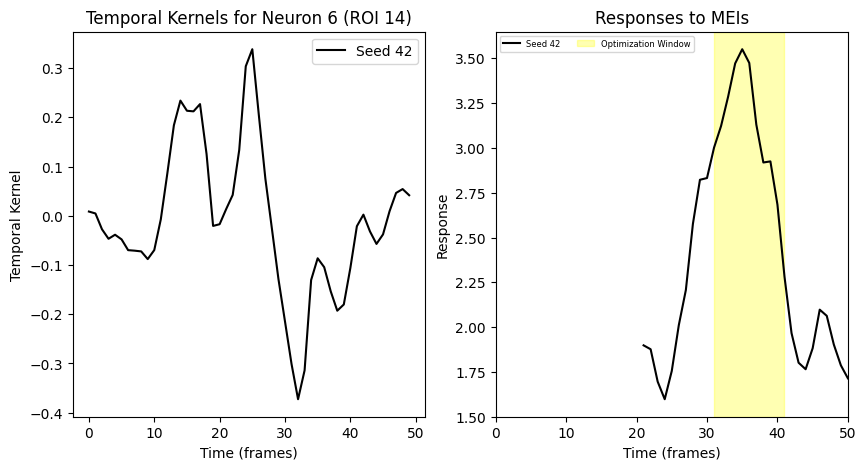

In [51]:
randomp_seed_mei_wrapper.plot1(roi_id=14)

In [18]:
import numpy as np
np.where(np.isnan(test_dict["online_session_1_ventral1_20200226"]["natural_spikes"][0]))

(array([   0,    1,    2,    3,    4,    5,    6,    7,    8,    9,   10,
          11,   12,   13,   14,   15,   16,   17,   18,   19,   20,   21,
          22,   23,   24,   25,   26,   27,   28,   29,   30,   31, 5004,
        5005, 5006, 5007, 5008, 5009, 5010, 5011, 5012, 5013, 5014, 5015,
        5016, 5017, 5018, 5019, 5020, 5021, 5022, 5023, 5024, 5025, 5026,
        5027, 5028, 5029, 5030, 5031, 5032, 5033, 5034, 5035]),)